# Phase 2: Three classifiers

Sequential build. We start with a shared evaluation module that all three classifiers will use, then build them one at a time.

1. Setup and load Phase 1 outputs
2. Shared evaluation module (metrics + confusion matrix + helpers)
3. Classifier 1: Pose + ML (logistic regression and SVM on keypoint features)
4. Classifier 2: CNN with transfer learning
5. Classifier 3: Vision LLM (GPT-5 mini)

**Inputs (from Phase 1):**
- `data/processed/keypoints.parquet` — one row per labeled frame, with metadata + 33 MediaPipe landmarks
- `data/processed/splits.json` — clip_id lists for train/val/test
- `data/processed/frames/` — JPGs of each event frame (used later by CNN and LLM)

## 1. Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROCESSED_DIR = Path('../data/processed')
RANDOM_SEED = 42

EVENT_NAMES = ['Address', 'Toe-up', 'Mid-backswing', 'Top',
               'Mid-downswing', 'Impact', 'Mid-followthrough', 'Finish']
NUM_LANDMARKS = 33

LEFT_RIGHT_PAIRS = [
    (1, 4), (2, 5), (3, 6), (7, 8), (9, 10),       # face
    (11, 12), (13, 14), (15, 16),                   # arms
    (17, 18), (19, 20), (21, 22),                   # hands
    (23, 24), (25, 26), (27, 28), (29, 30), (31, 32),  # legs
]

df_kp = pd.read_parquet(PROCESSED_DIR / 'keypoints.parquet')
with open(PROCESSED_DIR / 'splits.json') as f:
    splits = json.load(f)

print(f'Loaded keypoints: {df_kp.shape}')
print(f'Splits: train={len(splits["train"])} clips, val={len(splits["val"])} clips, test={len(splits["test"])} clips')
print(f'Total frames: {len(df_kp)}')
print(f'Frames per split: '
      f'train={len(df_kp[df_kp.clip_id.isin(splits["train"])])}, '
      f'val={len(df_kp[df_kp.clip_id.isin(splits["val"])])}, '
      f'test={len(df_kp[df_kp.clip_id.isin(splits["test"])])}')

df_kp.head()

Loaded keypoints: (2760, 108)
Splits: train=246 clips, val=39 clips, test=60 clips
Total frames: 2760
Frames per split: train=1968, val=312, test=480


,clip_id,player,sex,view,slow,handedness,event_idx,label,frame_filename,kp_x_0,...,kp_v_29,kp_x_30,kp_y_30,kp_v_30,kp_x_31,kp_y_31,kp_v_31,kp_x_32,kp_y_32,kp_v_32
0,1399,KENNY PERRY,m,down-the-line,1,R,1,Address,clip1399_event1.jpg,0.561053,...,0.816038,0.373482,0.965651,0.887343,0.512673,0.924629,0.896824,0.463517,0.965253,0.979659
1,1399,KENNY PERRY,m,down-the-line,1,R,2,Toe-up,clip1399_event2.jpg,0.532345,...,0.866845,0.384401,0.957379,0.884381,0.502987,0.934537,0.938468,0.437501,0.961633,0.980505
2,1399,KENNY PERRY,m,down-the-line,1,R,3,Mid-backswing,clip1399_event3.jpg,0.530872,...,0.837722,0.378789,0.963059,0.908408,0.512849,0.926530,0.946271,0.451025,0.966745,0.985412
3,1399,KENNY PERRY,m,down-the-line,1,R,4,Top,clip1399_event4.jpg,0.541007,...,0.791207,0.379667,0.969024,0.914073,0.516002,0.923873,0.900656,0.451443,0.966204,0.989892
4,1399,KENNY PERRY,m,down-the-line,1,R,5,Mid-downswing,clip1399_event5.jpg,0.540006,...,0.948225,0.375992,0.966570,0.954921,0.524518,0.929098,0.983719,0.455669,0.971069,0.995120


## 2. Shared evaluation module

All three classifiers will produce predictions in this format:

```python
predictions_df: pd.DataFrame with columns:
  - clip_id (int)
  - event_idx (int, 1-8)
  - true_label (str, one of EVENT_NAMES)
  - predicted_label (str, one of EVENT_NAMES)
  - confidence (float, probability of predicted_label, 0-1)
  - view (str, 'face-on' or 'down-the-line')
  - model (str, 'pose+lr', 'pose+svm', 'cnn', 'gpt4o-zero-shot', etc.)
```

Functions defined here are used by every classifier section below.

In [2]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
)


def compute_metrics(predictions_df: pd.DataFrame) -> dict:
    """Top-level metrics for a single model's predictions."""
    y_true = predictions_df['true_label'].values
    y_pred = predictions_df['predicted_label'].values
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', labels=EVENT_NAMES, zero_division=0),
        'macro_precision': precision_score(y_true, y_pred, average='macro', labels=EVENT_NAMES, zero_division=0),
        'macro_recall': recall_score(y_true, y_pred, average='macro', labels=EVENT_NAMES, zero_division=0),
        'n_samples': len(predictions_df),
    }


def per_class_metrics(predictions_df: pd.DataFrame) -> pd.DataFrame:
    """Per-class precision/recall/F1, indexed by event name."""
    y_true = predictions_df['true_label'].values
    y_pred = predictions_df['predicted_label'].values
    report = classification_report(
        y_true, y_pred, labels=EVENT_NAMES,
        output_dict=True, zero_division=0
    )
    rows = [{'event': name, **report[name]} for name in EVENT_NAMES if name in report]
    return pd.DataFrame(rows).set_index('event')


def per_view_metrics(predictions_df: pd.DataFrame) -> pd.DataFrame:
    """Top-level metrics broken down by view."""
    rows = []
    for view in ['face-on', 'down-the-line']:
        sub = predictions_df[predictions_df['view'] == view]
        if len(sub) == 0:
            continue
        m = compute_metrics(sub)
        m['view'] = view
        rows.append(m)
    return pd.DataFrame(rows).set_index('view')


def plot_confusion(predictions_df: pd.DataFrame, title: str = '', ax=None):
    """Confusion matrix as a normalized heatmap."""
    y_true = predictions_df['true_label'].values
    y_pred = predictions_df['predicted_label'].values
    cm = confusion_matrix(y_true, y_pred, labels=EVENT_NAMES, normalize='true')
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=EVENT_NAMES, yticklabels=EVENT_NAMES,
                cbar=False, ax=ax, annot_kws={'size': 8})
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    return ax


def evaluate_model(predictions_df: pd.DataFrame, model_name: str, show_plot: bool = True):
    """Full evaluation: prints metrics, returns dict, plots confusion."""
    print(f'\n{"=" * 60}')
    print(f'  {model_name}')
    print("=" * 60)
    overall = compute_metrics(predictions_df)
    print(f'  Accuracy:        {overall["accuracy"]:.4f}')
    print(f'  Macro F1:        {overall["macro_f1"]:.4f}')
    print(f'  Macro precision: {overall["macro_precision"]:.4f}')
    print(f'  Macro recall:    {overall["macro_recall"]:.4f}')
    print(f'  N samples:       {overall["n_samples"]}')

    print('\n--- Per class ---')
    print(per_class_metrics(predictions_df).round(3).to_string())

    print('\n--- Per view ---')
    pv = per_view_metrics(predictions_df)
    print(pv.round(3).to_string())

    if show_plot:
        plot_confusion(predictions_df, title=f'{model_name} — confusion matrix')
        plt.tight_layout()
        plt.show()

    return overall


rng = np.random.default_rng(RANDOM_SEED)
_test_pred = pd.DataFrame({
    'clip_id': [0, 0, 1, 1],
    'event_idx': [1, 2, 1, 2],
    'true_label': ['Address', 'Toe-up', 'Address', 'Toe-up'],
    'predicted_label': ['Address', 'Address', 'Toe-up', 'Toe-up'],
    'confidence': [0.9, 0.6, 0.7, 0.95],
    'view': ['face-on', 'face-on', 'down-the-line', 'down-the-line'],
    'model': 'smoke-test',
})
_smoke = compute_metrics(_test_pred)
print(f'Smoke test — accuracy on toy 4-row example: {_smoke["accuracy"]:.2f} (expected 0.50)')
assert abs(_smoke['accuracy'] - 0.5) < 1e-9, 'Eval module smoke test failed'
print('Eval module: OK')

Smoke test — accuracy on toy 4-row example: 0.50 (expected 0.50)
Eval module: OK


## 3. Classifier 1: Pose + ML

Logistic regression and linear SVM on engineered keypoint features.

### Feature engineering

We build feature vectors with three components:

1. **Raw normalized keypoint coordinates** — `kp_x_i, kp_y_i` for each of the 33 landmarks (66 features). MediaPipe normalizes these to [0, 1] within the frame.
2. **Joint angles** — angles at key body joints (elbow, shoulder, hip, knee), computed from triples of keypoints. ~10 features. These are scale/translation/rotation invariant body geometry.
3. **A view indicator** — one-hot for face-on vs down-the-line (1 feature). Lets the model behave differently per view without separate models.

We drop visibility scores (`kp_v_i`) — they vary noisily with frame quality and don't carry classification signal.

In [3]:
# MediaPipe landmark indices (subset we care about for joint angles)
LM = {
    'nose': 0,
    'left_shoulder': 11, 'right_shoulder': 12,
    'left_elbow': 13, 'right_elbow': 14,
    'left_wrist': 15, 'right_wrist': 16,
    'left_hip': 23, 'right_hip': 24,
    'left_knee': 25, 'right_knee': 26,
    'left_ankle': 27, 'right_ankle': 28,
}


def kp_xy(row, name):
    """Get (x, y) for a named landmark from a parquet row."""
    i = LM[name]
    return np.array([row[f'kp_x_{i}'], row[f'kp_y_{i}']])


def angle_at(b, a, c):
    """Angle at point b formed by points a-b-c. Returns degrees in [0, 180].
    
    a, b, c are 2D points (numpy arrays of shape (2,)).
    Used for elbow/knee/shoulder/hip joint angles.
    """
    ba = a - b
    bc = c - b
    norm_ba = np.linalg.norm(ba)
    norm_bc = np.linalg.norm(bc)
    if norm_ba < 1e-8 or norm_bc < 1e-8:
        return np.nan
    cos_ang = np.dot(ba, bc) / (norm_ba * norm_bc)
    cos_ang = np.clip(cos_ang, -1.0, 1.0)
    return np.degrees(np.arccos(cos_ang))


def joint_angles(row):
    """Compute the 10 joint angles we want as features."""
    angles = {}
    # Elbows: wrist - elbow - shoulder
    angles['left_elbow'] = angle_at(
        kp_xy(row, 'left_elbow'), kp_xy(row, 'left_wrist'), kp_xy(row, 'left_shoulder'))
    angles['right_elbow'] = angle_at(
        kp_xy(row, 'right_elbow'), kp_xy(row, 'right_wrist'), kp_xy(row, 'right_shoulder'))
    # Shoulders: elbow - shoulder - hip
    angles['left_shoulder'] = angle_at(
        kp_xy(row, 'left_shoulder'), kp_xy(row, 'left_elbow'), kp_xy(row, 'left_hip'))
    angles['right_shoulder'] = angle_at(
        kp_xy(row, 'right_shoulder'), kp_xy(row, 'right_elbow'), kp_xy(row, 'right_hip'))
    # Hips: shoulder - hip - knee
    angles['left_hip'] = angle_at(
        kp_xy(row, 'left_hip'), kp_xy(row, 'left_shoulder'), kp_xy(row, 'left_knee'))
    angles['right_hip'] = angle_at(
        kp_xy(row, 'right_hip'), kp_xy(row, 'right_shoulder'), kp_xy(row, 'right_knee'))
    # Knees: hip - knee - ankle
    angles['left_knee'] = angle_at(
        kp_xy(row, 'left_knee'), kp_xy(row, 'left_hip'), kp_xy(row, 'left_ankle'))
    angles['right_knee'] = angle_at(
        kp_xy(row, 'right_knee'), kp_xy(row, 'right_hip'), kp_xy(row, 'right_ankle'))
    # Lead arm orientation (angle of left arm from horizontal — useful for P3/P5 type events)
    left_arm_vec = kp_xy(row, 'left_wrist') - kp_xy(row, 'left_shoulder')
    angles['left_arm_horiz'] = np.degrees(np.arctan2(left_arm_vec[1], left_arm_vec[0]))
    # Torso rotation proxy: angle between shoulder-line and hip-line
    shoulder_vec = kp_xy(row, 'right_shoulder') - kp_xy(row, 'left_shoulder')
    hip_vec = kp_xy(row, 'right_hip') - kp_xy(row, 'left_hip')
    norm_s = np.linalg.norm(shoulder_vec)
    norm_h = np.linalg.norm(hip_vec)
    if norm_s > 1e-8 and norm_h > 1e-8:
        cos_ang = np.dot(shoulder_vec, hip_vec) / (norm_s * norm_h)
        angles['torso_rot'] = np.degrees(np.arccos(np.clip(cos_ang, -1.0, 1.0)))
    else:
        angles['torso_rot'] = np.nan
    return angles


def build_feature_matrix(df_subset):
    """Build (X, y, meta) for sklearn from a subset of the keypoints dataframe.
    
    Features:
      - 66 raw keypoint coords (x, y for 33 landmarks)
      - 10 joint angles (degrees)
      - 1 view indicator (0=face-on, 1=down-the-line)
    Total: 77 features.
    
    Returns:
      X: (N, 77) numpy array
      y: (N,) numpy array of string labels
      meta: DataFrame with clip_id, event_idx, view (for prediction tracking)
    """
    feature_rows = []
    labels = []
    meta = []
    for _, row in df_subset.iterrows():
        # Raw keypoint coords
        coords = []
        for i in range(NUM_LANDMARKS):
            coords.append(row[f'kp_x_{i}'])
            coords.append(row[f'kp_y_{i}'])
        # Joint angles
        ang = joint_angles(row)
        angles_list = [
            ang['left_elbow'], ang['right_elbow'],
            ang['left_shoulder'], ang['right_shoulder'],
            ang['left_hip'], ang['right_hip'],
            ang['left_knee'], ang['right_knee'],
            ang['left_arm_horiz'], ang['torso_rot'],
        ]
        # View indicator
        view_indicator = 1.0 if row['view'] == 'down-the-line' else 0.0

        feature_rows.append(coords + angles_list + [view_indicator])
        labels.append(row['label'])
        meta.append({'clip_id': row['clip_id'], 'event_idx': row['event_idx'], 'view': row['view']})

    X = np.array(feature_rows, dtype=np.float32)
    y = np.array(labels)
    return X, y, pd.DataFrame(meta)


FEATURE_NAMES = (
    [f'kp_{coord}_{i}' for i in range(NUM_LANDMARKS) for coord in ['x', 'y']] +
    ['left_elbow', 'right_elbow', 'left_shoulder', 'right_shoulder',
     'left_hip', 'right_hip', 'left_knee', 'right_knee',
     'left_arm_horiz', 'torso_rot'] +
    ['view_dtl']
)
print(f'Feature vector size: {len(FEATURE_NAMES)}')

Feature vector size: 77


### Filter low-quality detections and build the splits

Drop frames where MediaPipe failed (NaN keypoints) or had very low confidence. We also need to handle NaN joint angles, which can happen if two keypoints coincide.

In [4]:
# Filter out frames where the pose detection failed completely
vis_cols = [f'kp_v_{i}' for i in range(NUM_LANDMARKS)]
df_kp['mean_visibility'] = df_kp[vis_cols].mean(axis=1)
before = len(df_kp)
df_kp_clean = df_kp[df_kp['mean_visibility'] >= 0.3].copy()
after = len(df_kp_clean)
print(f'Dropped {before - after} frames with mean visibility < 0.3 ({100*(before-after)/before:.1f}%)')

def mirror_keypoint_row(row):
    """Mirror a single keypoint row: flip x to 1-x and swap left/right pair indices.

    A mirrored row represents the same swing in the opposite handedness orientation.
    Label stays the same (Mid-downswing is Mid-downswing regardless of handedness).
    """
    flipped = row.copy()
    # 1) Mirror x coordinates
    for i in range(NUM_LANDMARKS):
        flipped[f'kp_x_{i}'] = 1.0 - row[f'kp_x_{i}']
    # 2) Swap left/right pair contents
    for left_idx, right_idx in LEFT_RIGHT_PAIRS:
        for axis in ['x', 'y', 'v']:
            flipped[f'kp_{axis}_{left_idx}'] = row[f'kp_{axis}_{right_idx}']
            flipped[f'kp_{axis}_{right_idx}'] = row[f'kp_{axis}_{left_idx}']
    return flipped


df_train_orig = df_kp_clean[df_kp_clean['clip_id'].isin(splits['train'])].copy()
df_val = df_kp_clean[df_kp_clean['clip_id'].isin(splits['val'])].copy()
df_test = df_kp_clean[df_kp_clean['clip_id'].isin(splits['test'])].copy()

# Build mirrored copy of training set
df_train_mirrored = pd.DataFrame([
    mirror_keypoint_row(row) for _, row in df_train_orig.iterrows()
])

# Augmented train set: original + mirrored, 2× the original size
df_train = pd.concat([df_train_orig, df_train_mirrored], ignore_index=True)

print(f'Original train rows:   {len(df_train_orig)}')
print(f'Mirrored train rows:   {len(df_train_mirrored)}')
print(f'Augmented train total: {len(df_train)} (2× via mirror)')
print(f'Val rows:              {len(df_val)} (un-augmented)')
print(f'Test rows:             {len(df_test)} (un-augmented)')

X_train, y_train, meta_train = build_feature_matrix(df_train)
X_val,   y_val,   meta_val   = build_feature_matrix(df_val)
X_test,  y_test,  meta_test  = build_feature_matrix(df_test)

print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'X_val shape:   {X_val.shape},   y_val shape:   {y_val.shape}')
print(f'X_test shape:  {X_test.shape},  y_test shape:  {y_test.shape}')


Dropped 24 frames with mean visibility < 0.3 (0.9%)
Original train rows:   1953
Mirrored train rows:   1953
Augmented train total: 3906 (2× via mirror)
Val rows:              305 (un-augmented)
Test rows:             478 (un-augmented)
X_train shape: (3906, 77), y_train shape: (3906,)
X_val shape:   (305, 77),   y_val shape:   (305,)
X_test shape:  (478, 77),  y_test shape:  (478,)


### Train logistic regression and linear SVM

Both with feature standardization. We tune the regularization strength `C` on the validation set and report final results on the test set.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV


def predictions_dataframe(model, X, y_true, meta, model_name: str) -> pd.DataFrame:
    """Run model.predict and model.predict_proba, return our standard predictions df."""
    y_pred = model.predict(X)
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X)
        classes = model.classes_
        # Confidence = probability of the predicted class
        pred_idx = np.array([list(classes).index(p) for p in y_pred])
        confidence = proba[np.arange(len(y_pred)), pred_idx]
    else:
        confidence = np.ones(len(y_pred))  # SVM without calibration: no probabilities

    return pd.DataFrame({
        'clip_id': meta['clip_id'].values,
        'event_idx': meta['event_idx'].values,
        'true_label': y_true,
        'predicted_label': y_pred,
        'confidence': confidence,
        'view': meta['view'].values,
        'model': model_name,
    })


# Tune C on validation: try a few common values
best_c_lr, best_val_acc_lr = None, -1.0
for C in [0.1, 1.0, 10.0]:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(C=C, max_iter=2000, random_state=RANDOM_SEED)),
    ])
    pipe.fit(X_train, y_train)
    val_acc = pipe.score(X_val, y_val)
    print(f'  LR C={C}: val acc = {val_acc:.4f}')
    if val_acc > best_val_acc_lr:
        best_val_acc_lr = val_acc
        best_c_lr = C

print(f'\nBest LR C: {best_c_lr} (val acc {best_val_acc_lr:.4f})')

# Refit on train+val with best C, then predict on test
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(C=best_c_lr, max_iter=2000, random_state=RANDOM_SEED)),
])
lr_pipe.fit(X_trainval, y_trainval)
preds_lr = predictions_dataframe(lr_pipe, X_test, y_test, meta_test, 'pose+lr')

  LR C=0.1: val acc = 0.8951
  LR C=1.0: val acc = 0.9246
  LR C=10.0: val acc = 0.9213

Best LR C: 1.0 (val acc 0.9246)


In [6]:
# LinearSVC doesn't support predict_proba natively; wrap with CalibratedClassifierCV
best_c_svm, best_val_acc_svm = None, -1.0
for C in [0.1, 1.0, 10.0]:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', CalibratedClassifierCV(
            LinearSVC(C=C, max_iter=5000, random_state=RANDOM_SEED, dual='auto'),
            cv=3,
        )),
    ])
    pipe.fit(X_train, y_train)
    val_acc = pipe.score(X_val, y_val)
    print(f'  SVM C={C}: val acc = {val_acc:.4f}')
    if val_acc > best_val_acc_svm:
        best_val_acc_svm = val_acc
        best_c_svm = C

print(f'\nBest SVM C: {best_c_svm} (val acc {best_val_acc_svm:.4f})')

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', CalibratedClassifierCV(
        LinearSVC(C=best_c_svm, max_iter=5000, random_state=RANDOM_SEED, dual='auto'),
        cv=3,
    )),
])
svm_pipe.fit(X_trainval, y_trainval)
preds_svm = predictions_dataframe(svm_pipe, X_test, y_test, meta_test, 'pose+svm')

  SVM C=0.1: val acc = 0.8918
  SVM C=1.0: val acc = 0.9016
  SVM C=10.0: val acc = 0.9180

Best SVM C: 10.0 (val acc 0.9180)


### Evaluate Pose+ML


  Pose + Logistic Regression
  Accuracy:        0.8996
  Macro F1:        0.8989
  Macro precision: 0.8998
  Macro recall:    0.8992
  N samples:       478

--- Per class ---
                   precision  recall  f1-score  support
event                                                  
Address                0.862   0.933     0.896     60.0
Toe-up                 0.877   0.833     0.855     60.0
Mid-backswing          0.803   0.831     0.817     59.0
Top                    1.000   0.950     0.974     60.0
Mid-downswing          0.852   0.780     0.814     59.0
Impact                 0.921   0.967     0.943     60.0
Mid-followthrough      0.933   0.933     0.933     60.0
Finish                 0.951   0.967     0.959     60.0

--- Per view ---
               accuracy  macro_f1  macro_precision  macro_recall  n_samples
view                                                                       
face-on           0.905     0.906            0.908         0.905        232
down-the-line     

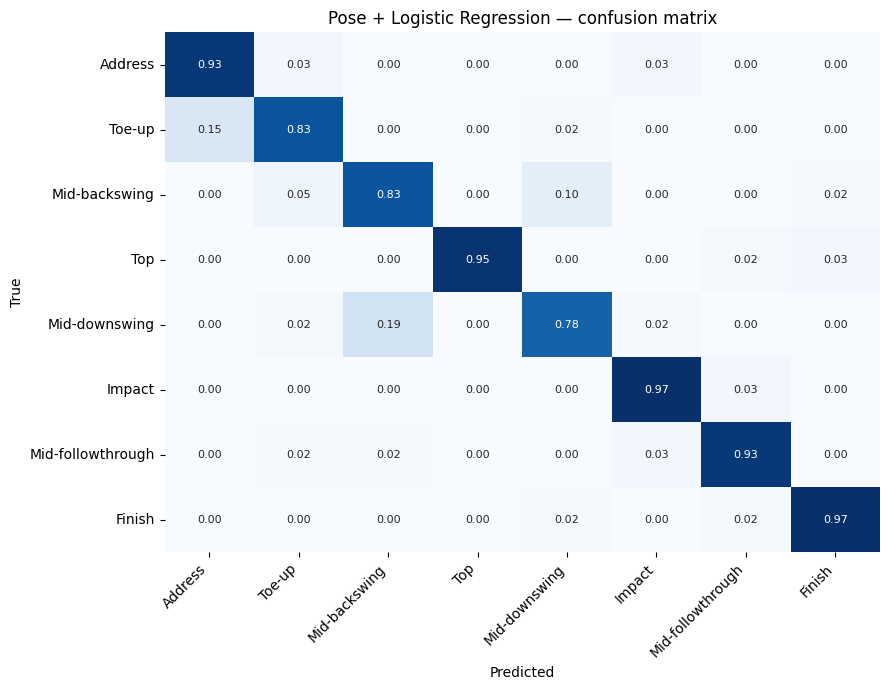


  Pose + Linear SVM
  Accuracy:        0.8849
  Macro F1:        0.8845
  Macro precision: 0.8851
  Macro recall:    0.8845
  N samples:       478

--- Per class ---
                   precision  recall  f1-score  support
event                                                  
Address                0.934   0.950     0.942     60.0
Toe-up                 0.912   0.867     0.889     60.0
Mid-backswing          0.738   0.763     0.750     59.0
Top                    0.934   0.950     0.942     60.0
Mid-downswing          0.839   0.797     0.817     59.0
Impact                 0.931   0.900     0.915     60.0
Mid-followthrough      0.857   0.900     0.878     60.0
Finish                 0.934   0.950     0.942     60.0

--- Per view ---
               accuracy  macro_f1  macro_precision  macro_recall  n_samples
view                                                                       
face-on           0.884     0.884            0.887         0.884        232
down-the-line     0.886    

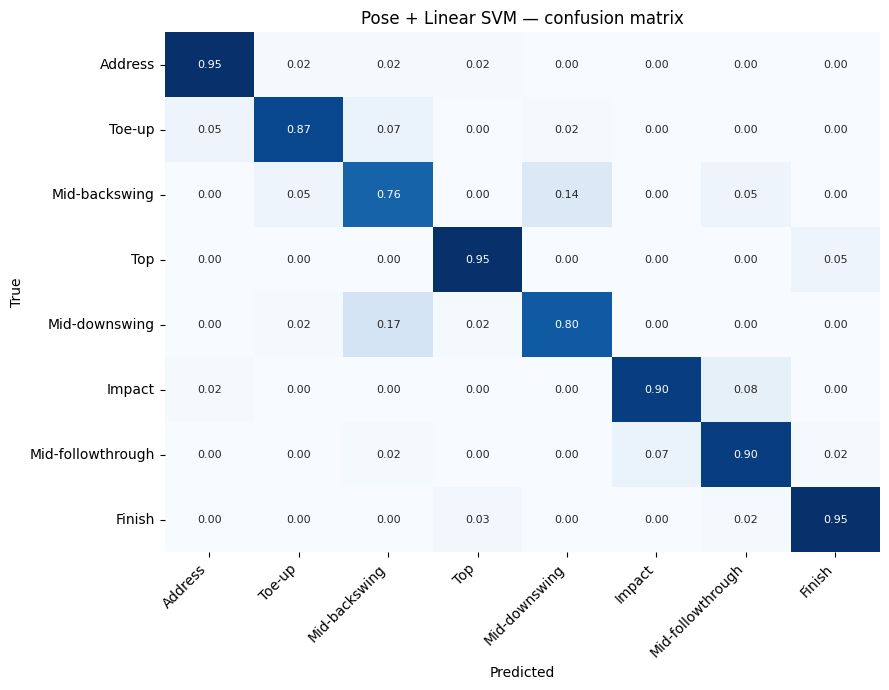

In [7]:
metrics_lr = evaluate_model(preds_lr, 'Pose + Logistic Regression')
metrics_svm = evaluate_model(preds_svm, 'Pose + Linear SVM')

### Save predictions for the cross-model comparison later

In [8]:
RESULTS_DIR = PROCESSED_DIR.parent / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

preds_lr.to_parquet(RESULTS_DIR / 'predictions_pose_lr.parquet', index=False)
preds_svm.to_parquet(RESULTS_DIR / 'predictions_pose_svm.parquet', index=False)
print(f'Saved Pose+ML predictions to {RESULTS_DIR}')

Saved Pose+ML predictions to ..\data\results


## 4. Classifier 2: CNN

In [9]:
import time
from copy import deepcopy

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version: {torch.__version__}')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

torch.manual_seed(RANDOM_SEED)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(RANDOM_SEED)

FRAMES_DIR = PROCESSED_DIR / 'frames'
EVENT_TO_IDX = {name: i for i, name in enumerate(EVENT_NAMES)}
IDX_TO_EVENT = {i: name for name, i in EVENT_TO_IDX.items()}


class GolfFramesDataset(Dataset):
    """Loads JPG frames from disk and returns (image_tensor, label_idx).
    
    The metadata DataFrame must contain 'frame_filename' and 'label' columns.
    Also returns clip_id, event_idx, and view per sample for prediction tracking.
    """
    def __init__(self, df_subset: pd.DataFrame, frames_dir: Path, transform=None):
        self.df = df_subset.reset_index(drop=True)
        self.frames_dir = frames_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.frames_dir / row['frame_filename']).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        label = EVENT_TO_IDX[row['label']]
        return img, label, int(row['clip_id']), int(row['event_idx']), row['view']


# ImageNet normalization (required for pretrained MobileNetV2)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(degrees=10),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomResizedCrop(size=224, scale=(0.85, 1.0), ratio=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_ds = GolfFramesDataset(df_train, FRAMES_DIR, transform=train_transform)
val_ds = GolfFramesDataset(df_val, FRAMES_DIR, transform=eval_transform)
test_ds = GolfFramesDataset(df_test, FRAMES_DIR, transform=eval_transform)

print(f'Train: {len(train_ds)} frames')
print(f'Val:   {len(val_ds)} frames')
print(f'Test:  {len(test_ds)} frames')

img, label, clip_id, event_idx, view = train_ds[0]
print(f'\nSample tensor shape: {img.shape}')
print(f'Sample label: {label} ({IDX_TO_EVENT[label]})')
print(f'Sample clip_id: {clip_id}, event_idx: {event_idx}, view: {view}')

PyTorch version: 2.11.0+cu126
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Ti
Train: 3906 frames
Val:   305 frames
Test:  478 frames

Sample tensor shape: torch.Size([3, 224, 224])
Sample label: 0 (Address)
Sample clip_id: 1399, event_idx: 1, view: down-the-line


### Model: MobileNetV2 with new classifier head

Load pretrained ImageNet weights, replace the final classification layer with one that outputs 8 logits (one per P-position event).

In [10]:
def build_model(n_classes: int = len(EVENT_NAMES)) -> nn.Module:
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V2)
    # MobileNetV2's classifier is Sequential(Dropout, Linear(1280, 1000))
    in_features = model.classifier[-1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, n_classes),
    )
    return model


model = build_model().to(device)
n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {n_params:,}')
print(f'Trainable parameters: {n_trainable:,}  (full fine-tuning)')

with torch.no_grad():
    test_batch = torch.zeros(2, 3, 224, 224).to(device)
    out = model(test_batch)
    print(f'\nForward pass output shape: {out.shape}  (expected (2, {len(EVENT_NAMES)}))')

Total parameters:     2,234,120
Trainable parameters: 2,234,120  (full fine-tuning)

Forward pass output shape: torch.Size([2, 8])  (expected (2, 8))


### Training loop

Adam + cosine LR schedule + early stopping on val accuracy.

In [11]:
BATCH_SIZE = 32
NUM_EPOCHS = 15
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 4   # stop if val acc doesn't improve for N epochs
NUM_WORKERS = 0               # 0 is safest on Windows; bump to 4 if you want faster loading

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda'),
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda'),
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda'),
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)


def run_epoch(model, loader, optimizer=None):
    """Run one epoch. If optimizer is None, do eval (no grad)."""
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, total_correct, total_samples = 0.0, 0, 0
    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for imgs, labels, *_ in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            logits = model(imgs)
            loss = criterion(logits, labels)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += imgs.size(0)
    return total_loss / total_samples, total_correct / total_samples


history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
best_val_acc = 0.0
best_state = None
epochs_without_improvement = 0

print(f'Training for up to {NUM_EPOCHS} epochs (early stop after {EARLY_STOPPING_PATIENCE} without improvement)')
print(f'Batch size: {BATCH_SIZE}, LR: {LEARNING_RATE}, Weight decay: {WEIGHT_DECAY}')
print('-' * 80)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = run_epoch(model, train_loader, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, optimizer=None)
    current_lr = scheduler.get_last_lr()[0]
    scheduler.step()
    elapsed = time.time() - t0

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    marker = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = deepcopy(model.state_dict())
        epochs_without_improvement = 0
        marker = '  *new best*'
    else:
        epochs_without_improvement += 1

    print(f'Epoch {epoch:2d}/{NUM_EPOCHS} | '
          f'train loss {train_loss:.4f} acc {train_acc:.4f} | '
          f'val loss {val_loss:.4f} acc {val_acc:.4f} | '
          f'lr {current_lr:.2e} | {elapsed:5.1f}s{marker}')

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f'\nEarly stopping triggered at epoch {epoch} (no val improvement for {EARLY_STOPPING_PATIENCE} epochs)')
        break

# Restore best weights
model.load_state_dict(best_state)
print(f'\nRestored best model (val acc {best_val_acc:.4f})')

Training for up to 15 epochs (early stop after 4 without improvement)
Batch size: 32, LR: 0.0003, Weight decay: 0.0001
--------------------------------------------------------------------------------
Epoch  1/15 | train loss 1.3158 acc 0.5233 | val loss 0.4103 acc 0.8557 | lr 3.00e-04 |  27.5s  *new best*
Epoch  2/15 | train loss 0.2750 acc 0.9071 | val loss 0.2237 acc 0.9246 | lr 2.97e-04 |  17.9s  *new best*
Epoch  3/15 | train loss 0.1767 acc 0.9380 | val loss 0.1365 acc 0.9541 | lr 2.87e-04 |  20.6s  *new best*
Epoch  4/15 | train loss 0.1043 acc 0.9670 | val loss 0.1466 acc 0.9410 | lr 2.71e-04 |  19.7s
Epoch  5/15 | train loss 0.0642 acc 0.9785 | val loss 0.1136 acc 0.9574 | lr 2.50e-04 |  19.5s  *new best*
Epoch  6/15 | train loss 0.0540 acc 0.9839 | val loss 0.2012 acc 0.9344 | lr 2.25e-04 |  19.4s
Epoch  7/15 | train loss 0.0518 acc 0.9834 | val loss 0.0960 acc 0.9574 | lr 1.96e-04 |  20.1s
Epoch  8/15 | train loss 0.0388 acc 0.9875 | val loss 0.1213 acc 0.9508 | lr 1.66e-04 |

### Training curves

Quick look at loss/accuracy over epochs to confirm the model converged and didn't overfit horribly.

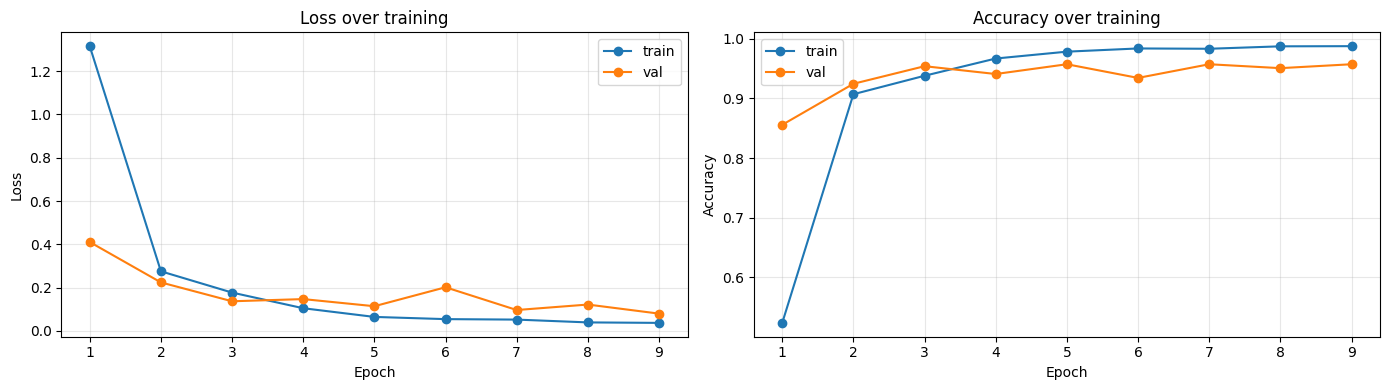

Final train acc: 0.9877
Best val acc:    0.9574
Train-val gap (overfitting indicator): +0.0303


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
epochs = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs, history['train_loss'], label='train', marker='o')
axes[0].plot(epochs, history['val_loss'], label='val', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss over training')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['train_acc'], label='train', marker='o')
axes[1].plot(epochs, history['val_acc'], label='val', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy over training')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Final train acc: {history["train_acc"][-1]:.4f}')
print(f'Best val acc:    {best_val_acc:.4f}')
print(f'Train-val gap (overfitting indicator): {history["train_acc"][-1] - best_val_acc:+.4f}')

### Predict on test set

In [13]:
def predict_cnn(model, loader, model_name: str = 'cnn-mobilenetv2') -> pd.DataFrame:
    """Run model on a loader, return predictions in the standard format."""
    model.eval()
    all_clip_ids, all_event_idxs, all_views = [], [], []
    all_true, all_pred, all_conf = [], [], []
    with torch.no_grad():
        for imgs, labels, clip_ids, event_idxs, views in loader:
            imgs = imgs.to(device)
            logits = model(imgs)
            probs = torch.softmax(logits, dim=1)
            confs, preds = probs.max(dim=1)

            all_clip_ids.extend(clip_ids.tolist())
            all_event_idxs.extend(event_idxs.tolist())
            all_views.extend(list(views))
            all_true.extend([IDX_TO_EVENT[i.item()] for i in labels])
            all_pred.extend([IDX_TO_EVENT[i.item()] for i in preds])
            all_conf.extend(confs.cpu().tolist())

    return pd.DataFrame({
        'clip_id': all_clip_ids,
        'event_idx': all_event_idxs,
        'true_label': all_true,
        'predicted_label': all_pred,
        'confidence': all_conf,
        'view': all_views,
        'model': model_name,
    })


preds_cnn = predict_cnn(model, test_loader)
preds_cnn.to_parquet(RESULTS_DIR / 'predictions_cnn.parquet', index=False)
CNN_WEIGHTS_PATH = Path('../data/results/cnn_mobilenetv2.pth')
CNN_WEIGHTS_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), CNN_WEIGHTS_PATH)
print(f'Saved CNN weights to {CNN_WEIGHTS_PATH}')
print(f'File size: {CNN_WEIGHTS_PATH.stat().st_size / 1024 / 1024:.1f} MB')
print(f'Saved CNN predictions to {RESULTS_DIR / "predictions_cnn.parquet"}')

Saved CNN weights to ..\data\results\cnn_mobilenetv2.pth
File size: 8.8 MB
Saved CNN predictions to ..\data\results\predictions_cnn.parquet


### Evaluate


  CNN — MobileNetV2 (full fine-tune)
  Accuracy:        0.9393
  Macro F1:        0.9393
  Macro precision: 0.9431
  Macro recall:    0.9392
  N samples:       478

--- Per class ---
                   precision  recall  f1-score  support
event                                                  
Address                0.870   1.000     0.930     60.0
Toe-up                 0.935   0.967     0.951     60.0
Mid-backswing          0.859   0.932     0.894     59.0
Top                    1.000   0.933     0.966     60.0
Mid-downswing          0.930   0.898     0.914     59.0
Impact                 1.000   0.850     0.919     60.0
Mid-followthrough      0.982   0.933     0.957     60.0
Finish                 0.968   1.000     0.984     60.0

--- Per view ---
               accuracy  macro_f1  macro_precision  macro_recall  n_samples
view                                                                       
face-on           0.944     0.944             0.95         0.944        232
down-the-l

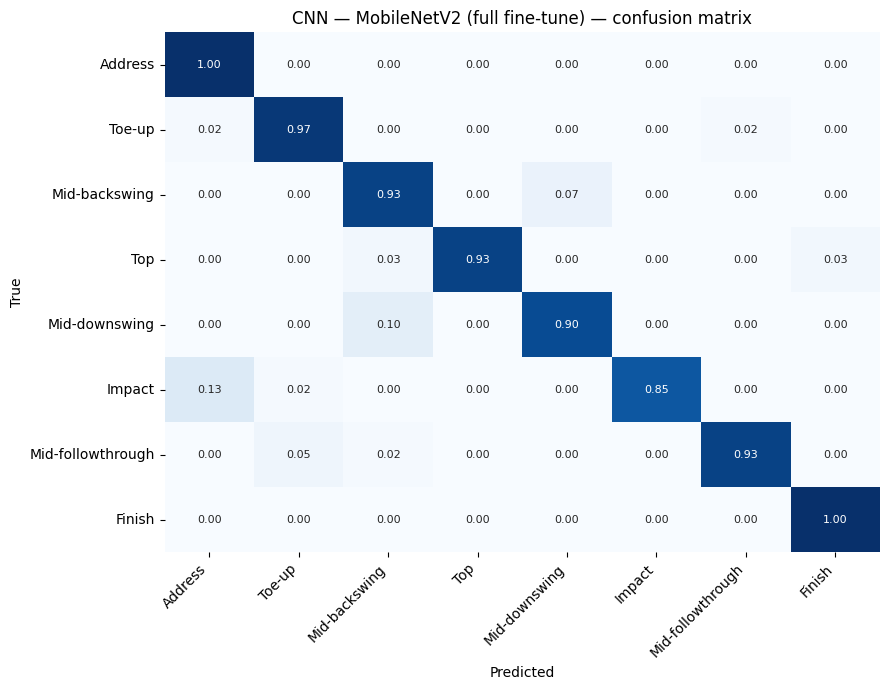

In [14]:
metrics_cnn = evaluate_model(preds_cnn, 'CNN — MobileNetV2 (full fine-tune)')

In [15]:
# Sanity: no clip should appear in more than one split
train_clips = set(df_train['clip_id'])
val_clips = set(df_val['clip_id'])
test_clips = set(df_test['clip_id'])

print(f'Train ∩ Val clips:  {len(train_clips & val_clips)}  (must be 0)')
print(f'Train ∩ Test clips: {len(train_clips & test_clips)} (must be 0)')
print(f'Val ∩ Test clips:   {len(val_clips & test_clips)}  (must be 0)')

# Sanity: no player should appear in more than one split
train_players = set(df_train['player'])
val_players = set(df_val['player'])
test_players = set(df_test['player'])

print(f'\nTrain ∩ Val players:  {len(train_players & val_players)}  (must be 0)')
print(f'Train ∩ Test players: {len(train_players & test_players)} (must be 0)')
print(f'Val ∩ Test players:   {len(val_players & test_players)}  (must be 0)')

Train ∩ Val clips:  0  (must be 0)
Train ∩ Test clips: 0 (must be 0)
Val ∩ Test clips:   0  (must be 0)

Train ∩ Val players:  0  (must be 0)
Train ∩ Test players: 0 (must be 0)
Val ∩ Test players:   0  (must be 0)


## 5. Classifier 3. Vision LLM

In [16]:
import base64
import os
import time
from typing import Optional

from dotenv import load_dotenv
from openai import OpenAI

load_dotenv('../.env')  # reads .env into environment variables

api_key = os.getenv('OPENAI_API_KEY')
if not api_key:
    raise RuntimeError('Set OPENAI_API_KEY in a .env file or your environment')

client = OpenAI(api_key=api_key)
MODEL_ID = 'gpt-5-mini'

# Setting these analyzing costs. So we dont overrun the token limits all of a sudden
INPUT_COST_PER_1K_TOK = 0.00025
OUTPUT_COST_PER_1K_TOK = 0.002

print(f'OpenAI client ready, model: {MODEL_ID}')

OpenAI client ready, model: gpt-5-mini


### Helpers: image encoding, prompt building, response parsing

In [17]:
def encode_image_base64(image_path: Path) -> str:
    """Read a JPG and return base64 string."""
    with open(image_path, 'rb') as f:
        return base64.b64encode(f.read()).decode('utf-8')


def image_content_block(image_path: Path, detail: str = 'low') -> dict:
    """Build the image content block for the OpenAI API.
    
    detail='low' uses ~85 tokens regardless of image size — much cheaper.
    detail='high' tiles the image and uses many more tokens.
    """
    b64 = encode_image_base64(image_path)
    return {
        'type': 'image_url',
        'image_url': {
            'url': f'data:image/jpeg;base64,{b64}',
            'detail': detail,
        },
    }


# Class definitions are shared across all three prompting strategies
CLASS_DEFINITIONS = '''The 8 swing positions are:
1. Address: golfer set up to the ball, club behind the ball, body still.
2. Toe-up: club shaft has just left the ball and is roughly waist-high in the takeaway, club face pointing up.
3. Mid-backswing: lead arm is roughly parallel to the ground during the backswing.
4. Top: top of the backswing, hands at their highest point, club pointing back.
5. Mid-downswing: lead arm is roughly parallel to the ground during the downswing (going forward, not back).
6. Impact: club is at the ball, body is rotated through.
7. Mid-followthrough: club has passed through impact and is going up the other side.
8. Finish: golfer is balanced on the front foot, body facing the target, club over the lead shoulder.'''


def parse_response_to_label(text: str) -> Optional[str]:
    """Extract one of the 8 EVENT_NAMES from a free-form response.
    
    Strategy: case-insensitive substring match for each canonical name.
    If multiple match, pick the one that appears latest in the text
    (most likely to be the final answer in CoT responses).
    """
    if not text:
        return None
    text_lower = text.lower()
    matches = [(name, text_lower.rfind(name.lower())) for name in EVENT_NAMES]
    matches = [(name, pos) for name, pos in matches if pos >= 0]
    if not matches:
        return None
    matches.sort(key=lambda x: x[1], reverse=True)
    return matches[0][0]


# Smoke test of the parser
_test_response = 'Looking at the body posture and arm position, this appears to be the Top of the backswing.'
assert parse_response_to_label(_test_response) == 'Top'
_test_response2 = 'Final answer: Mid-downswing'
assert parse_response_to_label(_test_response2) == 'Mid-downswing'
print('Parser smoke test: OK')

Parser smoke test: OK


### The three prompting strategies

In [18]:
ZERO_SHOT_SYSTEM = f'''You are an expert at classifying golf swing positions from a single video frame.

{CLASS_DEFINITIONS}

For each image, respond with ONLY the name of the swing position, exactly as written above (e.g., "Address" or "Mid-backswing"). No explanation.'''


COT_SYSTEM = f'''You are an expert at classifying golf swing positions from a single video frame.

{CLASS_DEFINITIONS}

For each image, reason step by step about what you see:
1. Describe the golfer's body position (stance, rotation, arm position).
2. Identify the position of the club shaft (where it points, its angle).
3. Compare what you see to the 8 swing position definitions and pick the best match.
4. End your response with: "Final answer: <swing position name>"'''


FEW_SHOT_SYSTEM = f'''You are an expert at classifying golf swing positions from a single video frame.

{CLASS_DEFINITIONS}

Below are 8 reference examples, one per class. After the examples, you will be shown a new image to classify.

Respond with ONLY the name of the swing position. No explanation.'''


def build_few_shot_examples_from_train():
    """Pick one good example image per class from the training set.
    
    'Good' = high pose detection confidence (mean visibility > 0.7) + face-on view
    so the examples are visually clear.
    """
    train_clip_ids = set(splits['train'])
    df_pool = df_kp_clean[
        df_kp_clean['clip_id'].isin(train_clip_ids)
        & (df_kp_clean['mean_visibility'] > 0.7)
        & (df_kp_clean['view'] == 'face-on')
    ]
    examples = {}
    rng_local = np.random.default_rng(RANDOM_SEED)
    for event_name in EVENT_NAMES:
        candidates = df_pool[df_pool['label'] == event_name]
        if len(candidates) == 0:
            # Fallback: any view, any visibility
            candidates = df_kp_clean[
                df_kp_clean['clip_id'].isin(train_clip_ids)
                & (df_kp_clean['label'] == event_name)
            ]
        chosen = candidates.iloc[rng_local.integers(len(candidates))]
        examples[event_name] = FRAMES_DIR / chosen['frame_filename']
    return examples


few_shot_examples = build_few_shot_examples_from_train()
print('Few-shot example images:')
for name, path in few_shot_examples.items():
    print(f'  {name}: {path.name}')

Few-shot example images:
  Address: clip1023_event1.jpg
  Toe-up: clip1389_event2.jpg
  Mid-backswing: clip0128_event3.jpg
  Top: clip0920_event4.jpg
  Mid-downswing: clip0804_event5.jpg
  Impact: clip1324_event6.jpg
  Mid-followthrough: clip0585_event7.jpg
  Finish: clip0205_event8.jpg


In [19]:
def call_zero_shot(image_path: Path) -> dict:
    response = client.chat.completions.create(
        model=MODEL_ID,
        messages=[
            {'role': 'system', 'content': ZERO_SHOT_SYSTEM},
            {'role': 'user', 'content': [
                {'type': 'text', 'text': 'Classify this swing position:'},
                image_content_block(image_path, detail='low'),
            ]},
        ],
        max_completion_tokens=200,
        reasoning_effort='low',
    )
    return {
        'text': response.choices[0].message.content,
        'input_tokens': response.usage.prompt_tokens,
        'output_tokens': response.usage.completion_tokens,
    }


def call_cot(image_path: Path) -> dict:
    response = client.chat.completions.create(
        model=MODEL_ID,
        messages=[
            {'role': 'system', 'content': COT_SYSTEM},
            {'role': 'user', 'content': [
                {'type': 'text', 'text': 'Classify this swing position. Reason step by step.'},
                image_content_block(image_path, detail='low'),
            ]},
        ],
        max_completion_tokens=800,
        reasoning_effort='medium',
    )
    return {
        'text': response.choices[0].message.content,
        'input_tokens': response.usage.prompt_tokens,
        'output_tokens': response.usage.completion_tokens,
    }


def call_few_shot(image_path: Path, example_paths: dict) -> dict:
    user_content = [{'type': 'text', 'text': 'Reference examples:'}]
    for name in EVENT_NAMES:
        user_content.append(image_content_block(example_paths[name], detail='low'))
        user_content.append({'type': 'text', 'text': f'Label: {name}'})
    user_content.append({'type': 'text', 'text': 'Now classify this new image:'})
    user_content.append(image_content_block(image_path, detail='low'))

    response = client.chat.completions.create(
        model=MODEL_ID,
        messages=[
            {'role': 'system', 'content': FEW_SHOT_SYSTEM},
            {'role': 'user', 'content': user_content},
        ],
        max_completion_tokens=200,
        reasoning_effort='low',
    )
    return {
        'text': response.choices[0].message.content,
        'input_tokens': response.usage.prompt_tokens,
        'output_tokens': response.usage.completion_tokens,
    }

### Smoke test on 50 frames

Tiny stratified subset (about 6 per class) to verify the pipeline works and the prompts produce sensible outputs.

We test all three strategies on the same 50 frames so they're directly comparable.

In [20]:
# Build the 50-frame stratified smoke-test set
rng_smoke = np.random.default_rng(RANDOM_SEED)
smoke_rows = []
samples_per_class = 50 // len(EVENT_NAMES)  # ~6 per class
for label in EVENT_NAMES:
    candidates = df_test[df_test['label'] == label]
    n = min(samples_per_class, len(candidates))
    chosen_idx = rng_smoke.choice(len(candidates), size=n, replace=False)
    smoke_rows.append(candidates.iloc[chosen_idx])
df_smoke = pd.concat(smoke_rows).reset_index(drop=True)
print(f'Smoke test set: {len(df_smoke)} frames')
print(df_smoke['label'].value_counts())

Smoke test set: 48 frames
label
Address              6
Toe-up               6
Mid-backswing        6
Top                  6
Mid-downswing        6
Impact               6
Mid-followthrough    6
Finish               6
Name: count, dtype: int64


In [ ]:
def run_strategy_on_subset(df_subset: pd.DataFrame, call_fn, model_name: str, **call_kwargs) -> tuple:
    """Run a prompting strategy on a subset of frames. Returns (predictions_df, total_cost)."""
    rows = []
    total_input, total_output = 0, 0
    t0 = time.time()

    for i, row in df_subset.reset_index(drop=True).iterrows():
        image_path = FRAMES_DIR / row['frame_filename']
        try:
            result = call_fn(image_path, **call_kwargs)
        except Exception as e:
            print(f'  Error on row {i} ({row["frame_filename"]}): {e}')
            continue

        predicted = parse_response_to_label(result['text'])
        if predicted is None:
            predicted = 'Address'

        rows.append({
            'clip_id': int(row['clip_id']),
            'event_idx': int(row['event_idx']),
            'true_label': row['label'],
            'predicted_label': predicted,
            'confidence': 1.0, 
            'view': row['view'],
            'model': model_name,
            'raw_response': result['text'],
        })
        total_input += result['input_tokens']
        total_output += result['output_tokens']

        if (i + 1) % 10 == 0 or i == len(df_subset) - 1:
            print(f'  {i + 1}/{len(df_subset)}  ({time.time() - t0:.0f}s elapsed)')

    cost = (total_input / 1000) * INPUT_COST_PER_1K_TOK + (total_output / 1000) * OUTPUT_COST_PER_1K_TOK
    print(f'  Total: {total_input} input + {total_output} output tokens = ${cost:.3f}')
    return pd.DataFrame(rows), cost


print('=== Smoke test: zero-shot ===')
preds_zs_smoke, cost_zs = run_strategy_on_subset(df_smoke, call_zero_shot, 'gpt4o-zero-shot')

print('\n=== Smoke test: chain-of-thought ===')
preds_cot_smoke, cost_cot = run_strategy_on_subset(df_smoke, call_cot, 'gpt4o-cot')

print('\n=== Smoke test: few-shot ===')
preds_fs_smoke, cost_fs = run_strategy_on_subset(
    df_smoke, call_few_shot, 'gpt4o-few-shot',
    example_paths=few_shot_examples,
)

print(f'\nTotal smoke-test API cost: ${cost_zs + cost_cot + cost_fs:.3f}')

=== Smoke test: zero-shot ===
  10/48  (20s elapsed)
  20/48  (56s elapsed)
  30/48  (79s elapsed)
  40/48  (103s elapsed)
  48/48  (121s elapsed)
  Total: 13056 input + 3242 output tokens = $0.010

=== Smoke test: chain-of-thought ===
  10/48  (69s elapsed)
  20/48  (153s elapsed)
  30/48  (244s elapsed)
  40/48  (322s elapsed)
  48/48  (374s elapsed)
  Total: 15552 input + 27892 output tokens = $0.060

=== Smoke test: few-shot ===
  10/48  (24s elapsed)
  20/48  (53s elapsed)
  30/48  (80s elapsed)
  40/48  (109s elapsed)
  48/48  (130s elapsed)
  Total: 26448 input + 4648 output tokens = $0.016

Total smoke-test API cost: $0.085


In [22]:
for preds_df, name in [
    (preds_zs_smoke, 'zero-shot'),
    (preds_cot_smoke, 'chain-of-thought'),
    (preds_fs_smoke, 'few-shot'),
]:
    acc = (preds_df['true_label'] == preds_df['predicted_label']).mean()
    print(f'  {name}: {acc:.3f} accuracy on {len(preds_df)} smoke frames')

# Show a couple of CoT responses to sanity-check the reasoning
print('\n--- Sample CoT responses ---')
for _, row in preds_cot_smoke.head(3).iterrows():
    correct = '✓' if row['true_label'] == row['predicted_label'] else '✗'
    print(f'\n[{correct}] True: {row["true_label"]}, Predicted: {row["predicted_label"]}')
    print(f'Response: {row["raw_response"][:300]}')

  zero-shot: 0.375 accuracy on 48 smoke frames
  chain-of-thought: 0.312 accuracy on 48 smoke frames
  few-shot: 0.417 accuracy on 48 smoke frames

--- Sample CoT responses ---

[✓] True: Address, Predicted: Address
Response: 1) Body position: The golfer is bent over at the hips with knees slightly flexed, weight appears evenly distributed, shoulders and hips square to the ball — there is no visible torso rotation through the shot and the head is down over the ball. Arms are extended but relaxed in front of the body rath

[✓] True: Address, Predicted: Address
Response: 1. Body position: The golfer is set over the ball with a narrow stance, knees slightly flexed, head down and eyes on the ball, and minimal torso rotation — appearing still and balanced.
2. Club shaft position: The club is positioned behind the ball with the shaft angled down toward the turf (near th

[✓] True: Address, Predicted: Address
Response: 1. The golfer is standing still with knees slightly flexed, feet set shoul

In [23]:
def call_zero_shot_high(image_path: Path) -> dict:
    response = client.chat.completions.create(
        model=MODEL_ID,
        messages=[
            {'role': 'system', 'content': ZERO_SHOT_SYSTEM},
            {'role': 'user', 'content': [
                {'type': 'text', 'text': 'Classify this swing position:'},
                image_content_block(image_path, detail='high'),
            ]},
        ],
        max_completion_tokens=200,
        reasoning_effort='low',
    )
    return {
        'text': response.choices[0].message.content,
        'input_tokens': response.usage.prompt_tokens,
        'output_tokens': response.usage.completion_tokens,
    }


def call_cot_high(image_path: Path) -> dict:
    response = client.chat.completions.create(
        model=MODEL_ID,
        messages=[
            {'role': 'system', 'content': COT_SYSTEM},
            {'role': 'user', 'content': [
                {'type': 'text', 'text': 'Classify this swing position. Reason step by step.'},
                image_content_block(image_path, detail='high'),
            ]},
        ],
        max_completion_tokens=800,
        reasoning_effort='medium',
    )
    return {
        'text': response.choices[0].message.content,
        'input_tokens': response.usage.prompt_tokens,
        'output_tokens': response.usage.completion_tokens,
    }


def call_few_shot_high(image_path: Path, example_paths: dict) -> dict:
    user_content = [{'type': 'text', 'text': 'Reference examples:'}]
    for name in EVENT_NAMES:
        user_content.append(image_content_block(example_paths[name], detail='high'))
        user_content.append({'type': 'text', 'text': f'Label: {name}'})
    user_content.append({'type': 'text', 'text': 'Now classify this new image:'})
    user_content.append(image_content_block(image_path, detail='high'))

    response = client.chat.completions.create(
        model=MODEL_ID,
        messages=[
            {'role': 'system', 'content': FEW_SHOT_SYSTEM},
            {'role': 'user', 'content': user_content},
        ],
        max_completion_tokens=200,
        reasoning_effort='low',
    )
    return {
        'text': response.choices[0].message.content,
        'input_tokens': response.usage.prompt_tokens,
        'output_tokens': response.usage.completion_tokens,
    }


print('=== HIGH-DETAIL ablation: zero-shot ===')
preds_zs_smoke_high, cost_zs_high = run_strategy_on_subset(
    df_smoke, call_zero_shot_high, 'gpt5mini-zs-high'
)

print('\n=== HIGH-DETAIL ablation: chain-of-thought ===')
preds_cot_smoke_high, cost_cot_high = run_strategy_on_subset(
    df_smoke, call_cot_high, 'gpt5mini-cot-high'
)

print('\n=== HIGH-DETAIL ablation: few-shot ===')
preds_fs_smoke_high, cost_fs_high = run_strategy_on_subset(
    df_smoke, call_few_shot_high, 'gpt5mini-fs-high',
    example_paths=few_shot_examples,
)

print(f'\nTotal high-detail ablation cost: ${cost_zs_high + cost_cot_high + cost_fs_high:.3f}')
print(f'(Previous low-detail smoke cost: ${cost_zs + cost_cot + cost_fs:.3f})')

print('\n=== LOW vs HIGH detail accuracy on same 48 frames ===')
for low, high, name in [
    (preds_zs_smoke, preds_zs_smoke_high, 'zero-shot'),
    (preds_cot_smoke, preds_cot_smoke_high, 'chain-of-thought'),
    (preds_fs_smoke, preds_fs_smoke_high, 'few-shot'),
]:
    acc_low = (low['true_label'] == low['predicted_label']).mean()
    acc_high = (high['true_label'] == high['predicted_label']).mean()
    delta = acc_high - acc_low
    print(f'  {name:20s}: low={acc_low:.3f}  high={acc_high:.3f}  Δ={delta:+.3f}')

print('\n=== Per-class accuracy: HIGH-DETAIL ===')
for preds_df, name in [
    (preds_zs_smoke_high, 'zero-shot'),
    (preds_cot_smoke_high, 'chain-of-thought'),
    (preds_fs_smoke_high, 'few-shot'),
]:
    print(f'\n--- {name} ---')
    df = preds_df.copy()
    df['correct'] = df['true_label'] == df['predicted_label']
    print(df.groupby('true_label')['correct'].agg(['sum', 'count', 'mean']).round(2))

=== HIGH-DETAIL ablation: zero-shot ===
  10/48  (24s elapsed)
  20/48  (50s elapsed)
  30/48  (71s elapsed)
  40/48  (97s elapsed)
  48/48  (116s elapsed)
  Total: 13056 input + 3181 output tokens = $0.010

=== HIGH-DETAIL ablation: chain-of-thought ===
  10/48  (93s elapsed)
  20/48  (174s elapsed)
  30/48  (261s elapsed)
  40/48  (358s elapsed)
  48/48  (428s elapsed)
  Total: 15552 input + 27648 output tokens = $0.059

=== HIGH-DETAIL ablation: few-shot ===
  10/48  (33s elapsed)
  20/48  (66s elapsed)
  Error on row 26 (clip0301_event5.jpg): Error code: 400 - {'error': {'message': 'Could not finish the message because max_tokens or model output limit was reached. Please try again with higher max_tokens.', 'type': 'invalid_request_error', 'param': None, 'code': None}}
  30/48  (101s elapsed)
  40/48  (130s elapsed)
  48/48  (149s elapsed)
  Total: 25897 input + 4643 output tokens = $0.016

Total high-detail ablation cost: $0.085
(Previous low-detail smoke cost: $0.085)

=== LOW vs 

In [24]:
preds_zs_smoke_high.to_parquet(RESULTS_DIR / 'predictions_gpt5mini_zs_high.parquet', index=False)
preds_cot_smoke_high.to_parquet(RESULTS_DIR / 'predictions_gpt5mini_cot_high.parquet', index=False)
preds_fs_smoke_high.to_parquet(RESULTS_DIR / 'predictions_gpt5mini_fs_high.parquet', index=False)

# Also save low-detail predictions for the appendix table I recommended
preds_zs_smoke.to_parquet(RESULTS_DIR / 'predictions_gpt5mini_zs_low.parquet', index=False)
preds_cot_smoke.to_parquet(RESULTS_DIR / 'predictions_gpt5mini_cot_low.parquet', index=False)
preds_fs_smoke.to_parquet(RESULTS_DIR / 'predictions_gpt5mini_fs_low.parquet', index=False)